# IRIS FLOWER CLASSIFICATION

#### The Iris Flower Dataset is one of the most popular datasets used for introductory classification problems.
#### In this, a machine learning model is developed to classify Iris flowers into three species:
###  Setosa
###  Versicolor
###  Virginica
#### based on their sepal and petal measurements.

## Import required libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Load the Iris dataset

In [2]:
df = pd.read_csv("Iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df['species'],categories =pd.factorize(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Display dataset information

In [4]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
df.shape

(150, 5)

In [7]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

## Data Visualization

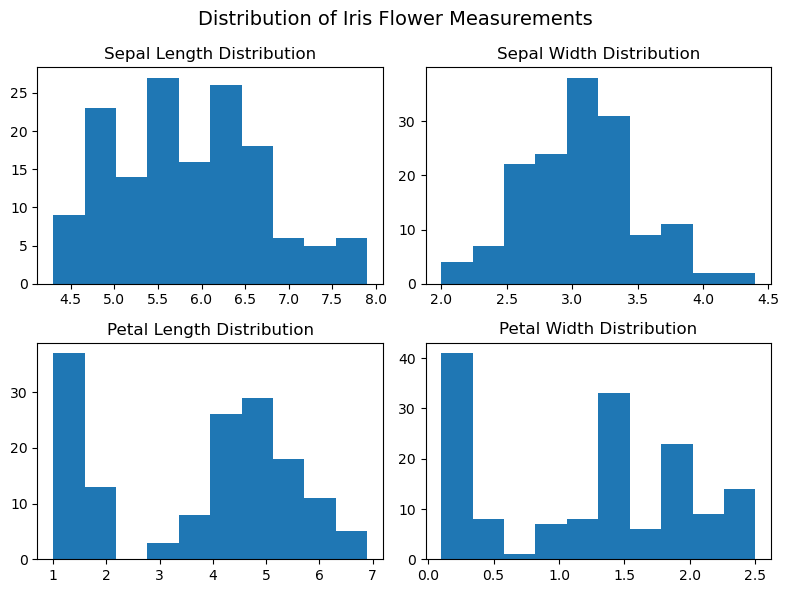

In [9]:
# Histogram visualization code for distribution of numerical variables
plt.figure(figsize=(8, 6))
plt.suptitle('Distribution of Iris Flower Measurements', fontsize=14)
plt.subplot(2, 2, 1) 
plt.hist(df['sepal_length'])
plt.title('Sepal Length Distribution')
plt.subplot(2, 2, 2)
plt.hist(df['sepal_width'])
plt.title('Sepal Width Distribution')
plt.subplot(2, 2, 3) 
plt.hist(df['petal_length'])
plt.title('Petal Length Distribution')
plt.subplot(2, 2, 4) 
plt.hist(df['petal_width'])
plt.title('Petal Width Distribution')
plt.tight_layout() 
plt.show()

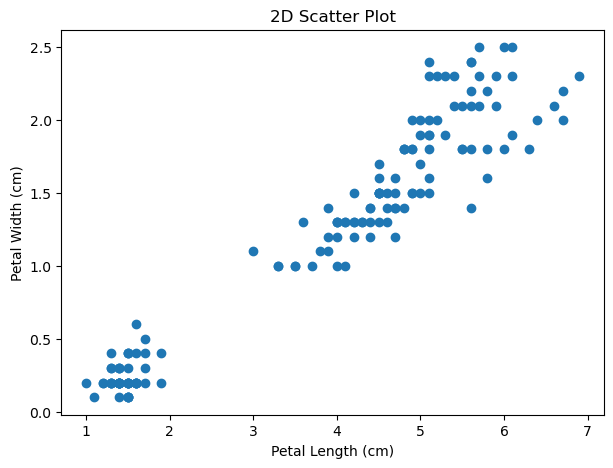

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(df.petal_length,df.petal_width)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("2D Scatter Plot")
plt.show()

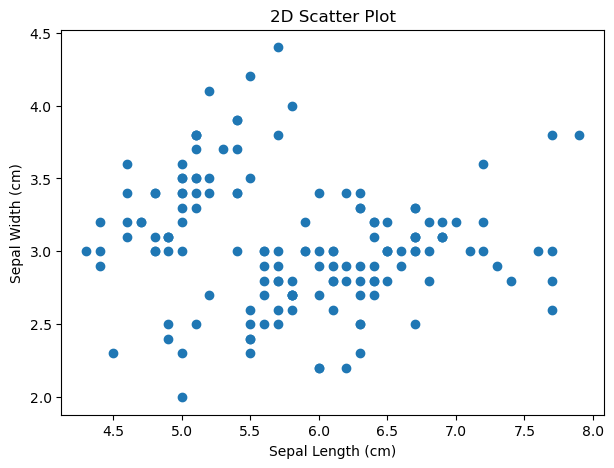

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(df.sepal_length,df.sepal_width)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("2D Scatter Plot")
plt.show()

In [12]:
# Map target values to species names
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

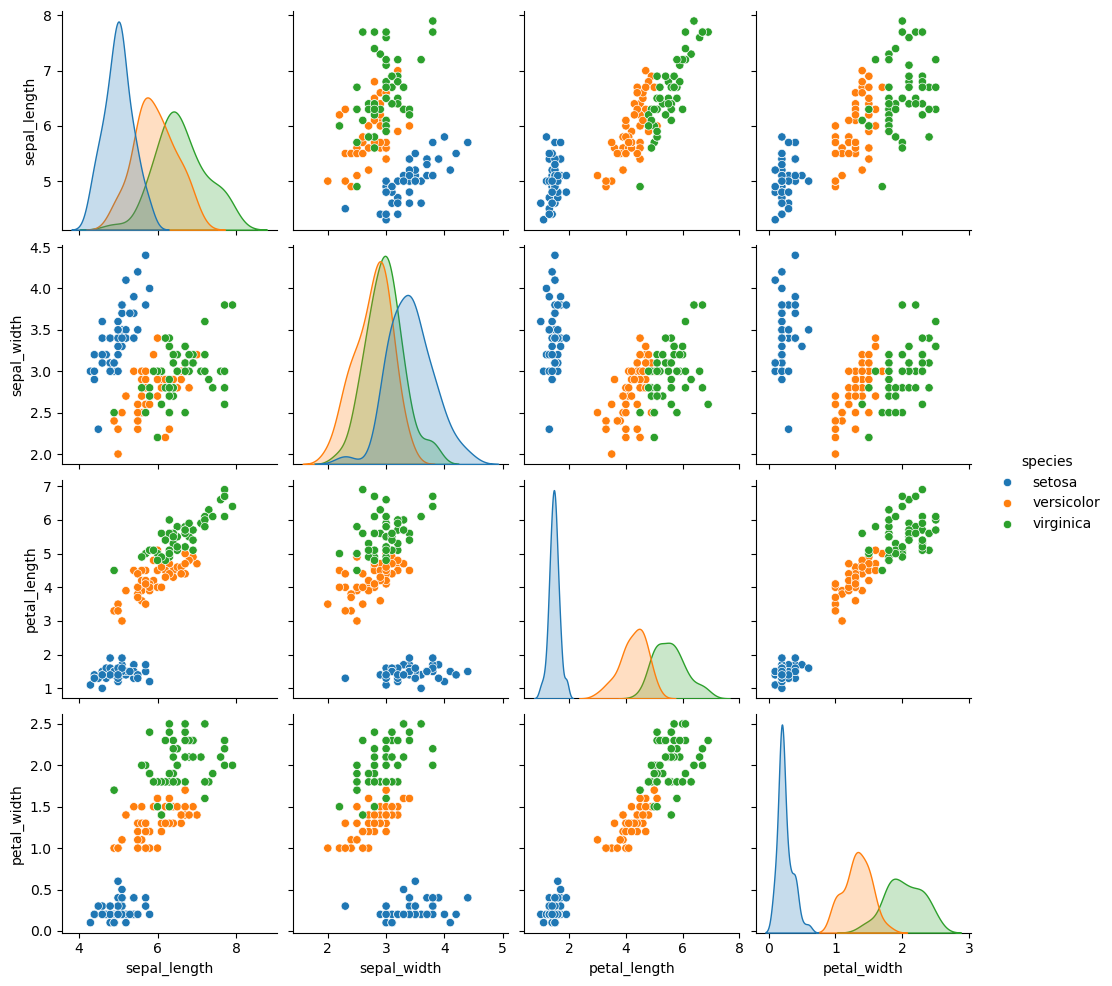

In [13]:
sns.pairplot(df, hue='species')
plt.show()

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

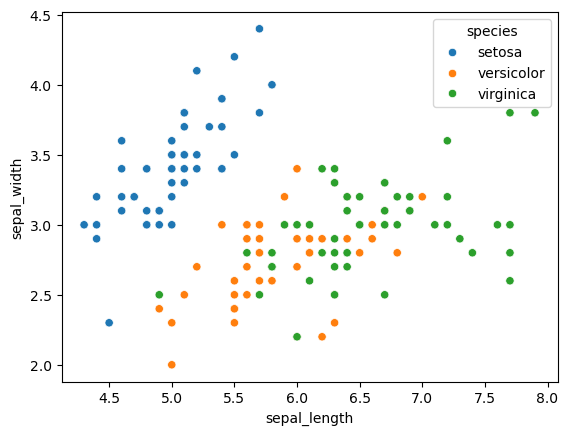

In [14]:
sns.scatterplot(data=df, x="sepal_length", y="sepal_width",hue="species")

<Axes: xlabel='petal_length', ylabel='petal_width'>

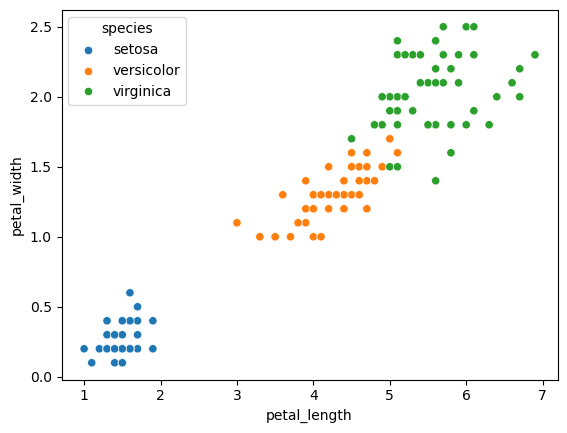

In [15]:
sns.scatterplot(data=df, x="petal_length", y="petal_width",hue="species")

### Split features and target

In [16]:
# Split Data into Features and Target
X = df.drop('species', axis=1)
y = df['species']

In [18]:
X.shape

(150, 4)

In [102]:
y.shape

(150,)

## Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train.shape

(120, 4)

## Train the model

In [21]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

## Making Predictions

In [22]:
y_pred = model.predict(X_test)
y_pred

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

##  Evaluate model performance

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### Confusion Matrix

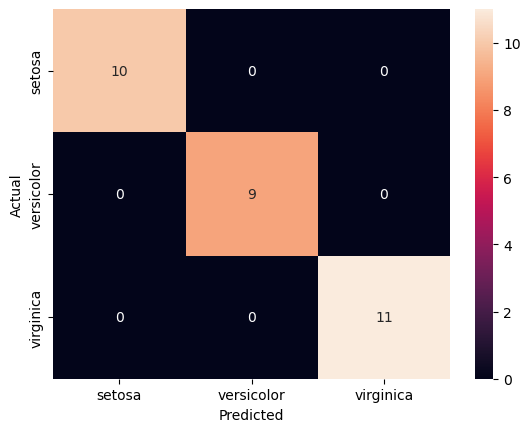

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Predict New Flower

In [25]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)
print("Predicted Species:", prediction[0])

Predicted Species: setosa


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Conclusion
#### In this, a machine learning model was successfully built to classify Iris flowers into different species.
#### Logistic Regression proved to be highly effective due to the simplicity and linear separability of the dataset.